# Notebook de validación

Cuaderno de apoyo para revisar el comportamiento del pipeline secuencial actual sobre el hold-out.

- trabaja con ventanas temporales
- compara `LSTM` y `GRU`
- revisa métricas agregadas y por clase
- muestra figuras de evaluación persistidas por el flujo oficial


## Criterio de validación

La validación se realiza sobre secuencias agrupadas por `sample_id`, con estratificación por
`target_global`, evitando que ventanas de una misma serie aparezcan simultáneamente en train y test.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from IPython.display import display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "config" / "config.yaml").exists():
    ROOT = ROOT.parent

summary = json.loads((ROOT / "models" / "metrics" / "metrics_summary.json").read_text(encoding="utf-8"))
comparison = pd.read_csv(ROOT / "models" / "metrics" / "model_comparison.csv")
lstm_report = pd.read_csv(ROOT / "models" / "metrics" / "lstm_class_report.csv")
gru_report = pd.read_csv(ROOT / "models" / "metrics" / "gru_class_report.csv")

display(comparison)
display(lstm_report)
display(gru_report)


,model_name,selection_metric,selection_value,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,log_loss,predictions_file
0,gru,f1_macro,0.943587,0.941441,0.945202,0.943587,0.942235,0.945202,0.183020,data\predictions\holdout_predictions_gru.csv
1,lstm,f1_macro,0.932763,0.930180,0.934612,0.932763,0.931277,0.934612,0.209667,data\predictions\holdout_predictions_lstm.csv


,class_id,class_name,precision,recall,f1,support
0,0,sano,0.940657,0.917488,0.928928,812
1,1,insectos,0.906801,0.901126,0.903955,799
2,2,moho_critico,0.946372,0.985222,0.965406,609


,class_id,class_name,precision,recall,f1,support
0,0,sano,0.947631,0.935961,0.941760,812
1,1,insectos,0.925032,0.911139,0.918033,799
2,2,moho_critico,0.954041,0.988506,0.970968,609


## Búsqueda e historial

Este bloque deja visible la exploración de configuraciones para que la selección del modelo no se perciba
como una decisión ad hoc.


In [2]:
lstm_search = pd.read_csv(ROOT / "models" / "metrics" / "lstm_search_summary.csv")
gru_search = pd.read_csv(ROOT / "models" / "metrics" / "gru_search_summary.csv")
score_col = "selection_value" if "selection_value" in lstm_search.columns else "f1_macro"
display(lstm_search.sort_values(score_col, ascending=False).head())
display(gru_search.sort_values(score_col, ascending=False).head())


,model_type,trial_id,selection_metric,selection_value,val_accuracy,val_balanced_accuracy,val_f1_macro,val_precision_macro,val_recall_macro,val_log_loss,params
0,lstm,2,f1_macro,0.946649,0.944745,0.946246,0.946649,0.947170,0.946246,0.176173,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
1,lstm,4,f1_macro,0.946123,0.944745,0.946071,0.946123,0.946397,0.946071,0.174312,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
2,lstm,6,f1_macro,0.944067,0.942342,0.945165,0.944067,0.944888,0.945165,0.180724,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
3,lstm,7,f1_macro,0.943760,0.941742,0.942751,0.943760,0.944898,0.942751,0.167537,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
4,lstm,5,f1_macro,0.942338,0.940541,0.942398,0.942338,0.942570,0.942398,0.168643,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."


,model_type,trial_id,selection_metric,selection_value,val_accuracy,val_balanced_accuracy,val_f1_macro,val_precision_macro,val_recall_macro,val_log_loss,params
0,gru,3,f1_macro,0.954294,0.953153,0.954509,0.954294,0.954315,0.954509,0.145483,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
1,gru,4,f1_macro,0.953092,0.951351,0.953925,0.953092,0.952365,0.953925,0.142991,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
2,gru,5,f1_macro,0.951110,0.948949,0.951174,0.951110,0.951085,0.951174,0.162831,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
3,gru,6,f1_macro,0.949757,0.948348,0.949371,0.949757,0.950263,0.949371,0.147279,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."
4,gru,7,f1_macro,0.949440,0.947748,0.949356,0.949440,0.949528,0.949356,0.148947,"{""batch_size"": 64, ""bidirectional"": false, ""dr..."


In [3]:
acceptance = pd.DataFrame(summary.get("acceptance_check", {}).get("checks", []))
if not acceptance.empty:
    display(acceptance)
    print("Resultado global de aceptacion:", summary["acceptance_check"].get("overall_passed"))


,name,metric,operator,required,actual,passed
0,f1_macro_min,f1_macro,>=,0.90,0.943587,True
1,recall_macro_min,recall_macro,>=,0.90,0.945202,True
2,accuracy_min,accuracy,>=,0.90,0.941441,True
3,log_loss_max,log_loss,<=,0.20,0.183020,True
4,class_recall_min.moho_critico,moho_critico.recall,>=,0.95,0.988506,True


Resultado global de aceptacion: True


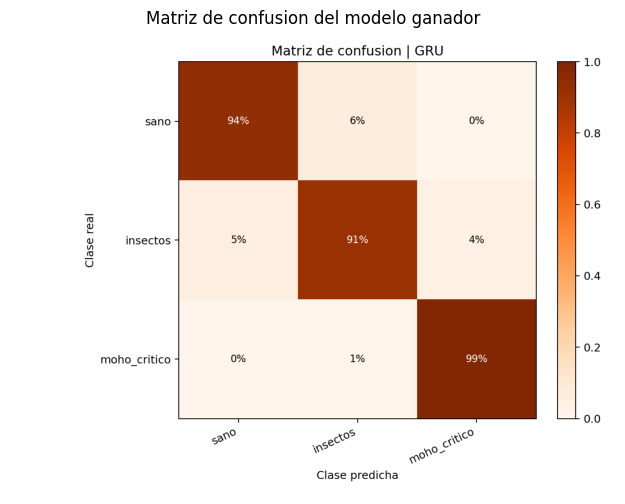

In [4]:
fig_path = ROOT / "models" / "metrics" / "figures" / "winner_confusion.png"
img = imread(fig_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Matriz de confusion del modelo ganador")
plt.show()


## Evidencia temporal

La evaluación genera una traza temporal completa y un foco de arranque para revisar probabilidades,
clase real y predicción en el comportamiento temprano de una serie de hold-out.


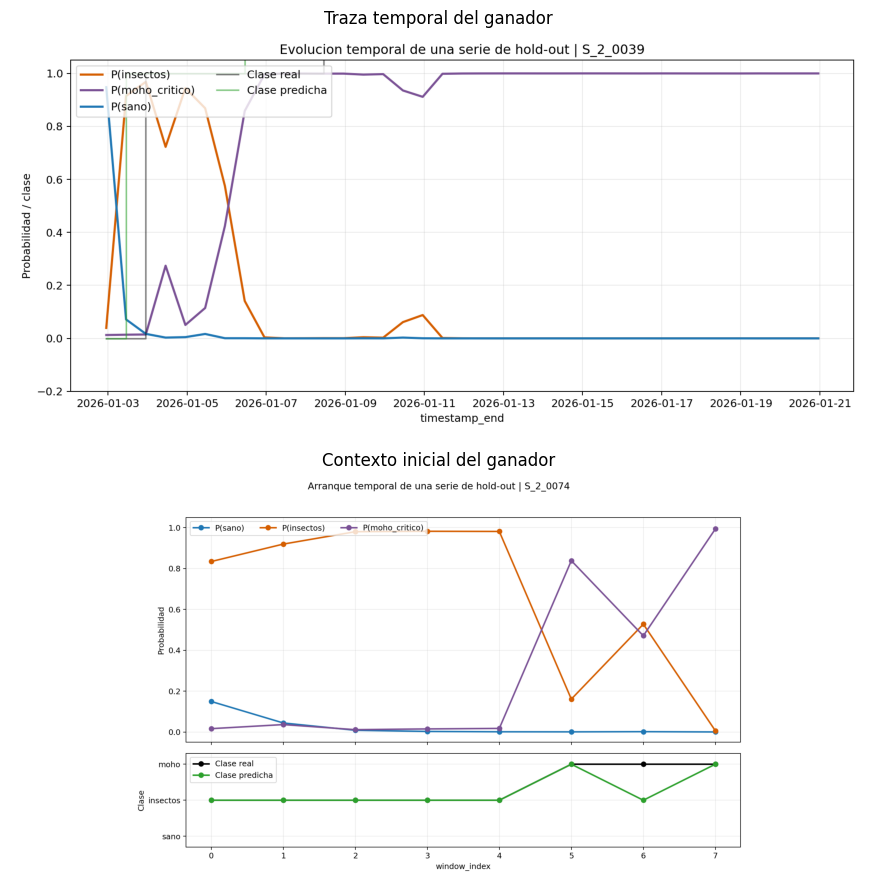

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for ax, name, title in zip(
    axes,
    ["winner_temporal_trace.png", "winner_initial_context.png"],
    ["Traza temporal del ganador", "Contexto inicial del ganador"],
):
    img = imread(ROOT / "models" / "metrics" / "figures" / name)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()
